<a href="https://colab.research.google.com/github/mocha-dts/DataScience_240401010041_M.Rochmatullah/blob/main/Pertemuan4_MochamadRochmatullah_240401010041.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Nama Lengkap  : Mochamad Rochmatullah
#### NIM           : 240401010041
#### Kelas         : IF403


# **Sesi 4 – Statistika Dasar & Analisis Data**

#### STEP 1 — Load & Inspect Dataset

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
df = sns.load_dataset('iris')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

#### STEP 2 — Statistik Deskriptif Lengkap

In [ ]:
for col_name in df.select_dtypes(include='number').columns:
 col = df[col_name]
 print(f'\n=== {col_name} ===')
 print(f' Mean : {col.mean():.3f}')
 print(f' Median : {col.median():.3f}')
 print(f' Std Dev : {col.std():.3f}')
 print(f' Skewness : {col.skew():.3f}')
 print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


#### STEP 3 — Analisis Distribusi (Histogram + KDE)

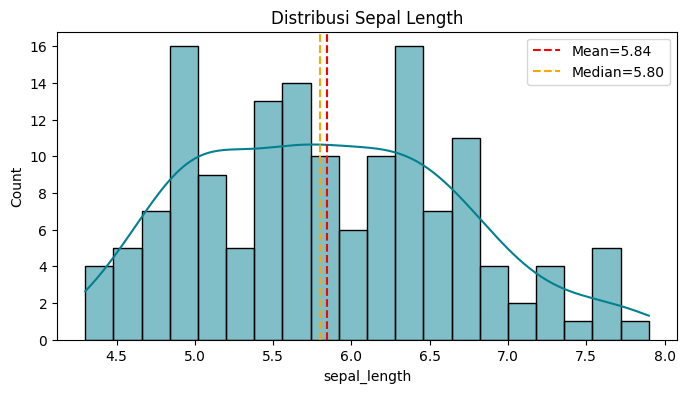


Hasil Identifikasi:
Distribusi Menceng Kanan (Right-Skewed / Positively Skewed) meskipun terlihat memiliki beberapa puncak (multimodal)


In [ ]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean={df['sepal_length'].mean():.2f}"
)

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median={df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.legend()

plt.show()

print("\nHasil Identifikasi:")
print(f"Distribusi Menceng Kanan (Right-Skewed / Positively Skewed) meskipun terlihat memiliki beberapa puncak (multimodal)")

#### STEP 4 — Boxplot per Spesies

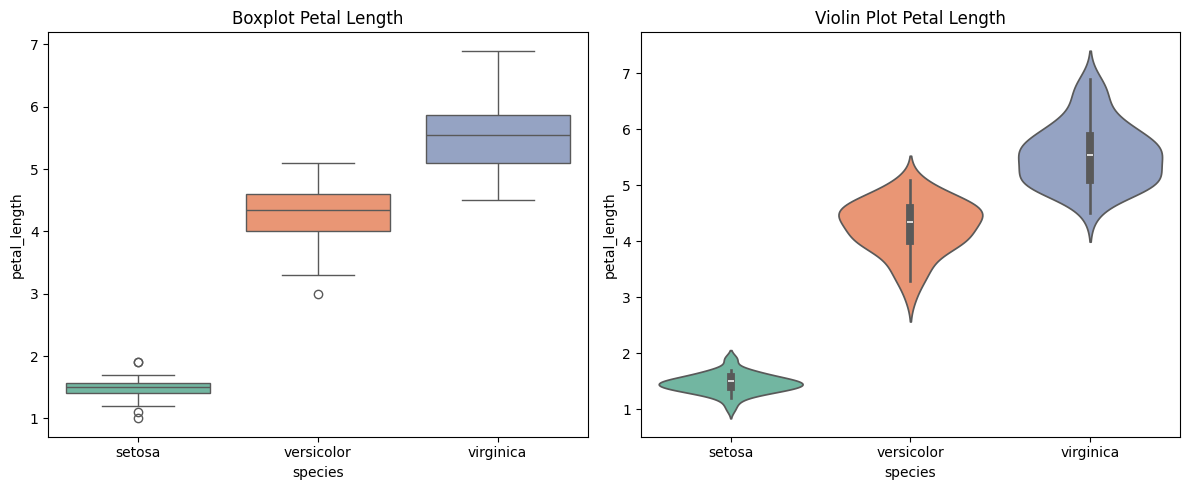

             mean  min  max    std
species                           
setosa      1.462  1.0  1.9  0.174
versicolor  4.260  3.0  5.1  0.470
virginica   5.552  4.5  6.9  0.552

Hasil Identifikasi:
- Spesies dengan petal_length terbesar : virginica
- Spesies dengan petal_length terkecil : setosa
- Spesies dengan penyebaran paling besar : virginica


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    legend=False,
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

summary = df.groupby('species')['petal_length'].agg(['mean', 'min', 'max', 'std'])

print(summary.round(3))

species_terbesar = summary['mean'].idxmax()
species_terkecil = summary['mean'].idxmin()
species_tersebar = summary['std'].idxmax()

print("\nHasil Identifikasi:")
print(f"- Spesies dengan petal_length terbesar : {species_terbesar}")
print(f"- Spesies dengan petal_length terkecil : {species_terkecil}")
print(f"- Spesies dengan penyebaran paling besar : {species_tersebar}")

#### STEP 5 — Matriks Korelasi Pearson

In [ ]:
corr = df.drop('species', axis=1).corr(method='pearson')

print("Matriks Korelasi:")
print(corr.round(3))


import numpy as np

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print("\nHasil Identifikasi:")
print(f"Korelasi tertinggi : {max_pair} = {corr.loc[max_pair]:.3f}")
print(f"Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}")


Matriks Korelasi:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Hasil Identifikasi:
Korelasi tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi terendah  : ('petal_length', 'sepal_width') = -0.428


#### STEP 6 — Scatter Plot & Heatmap

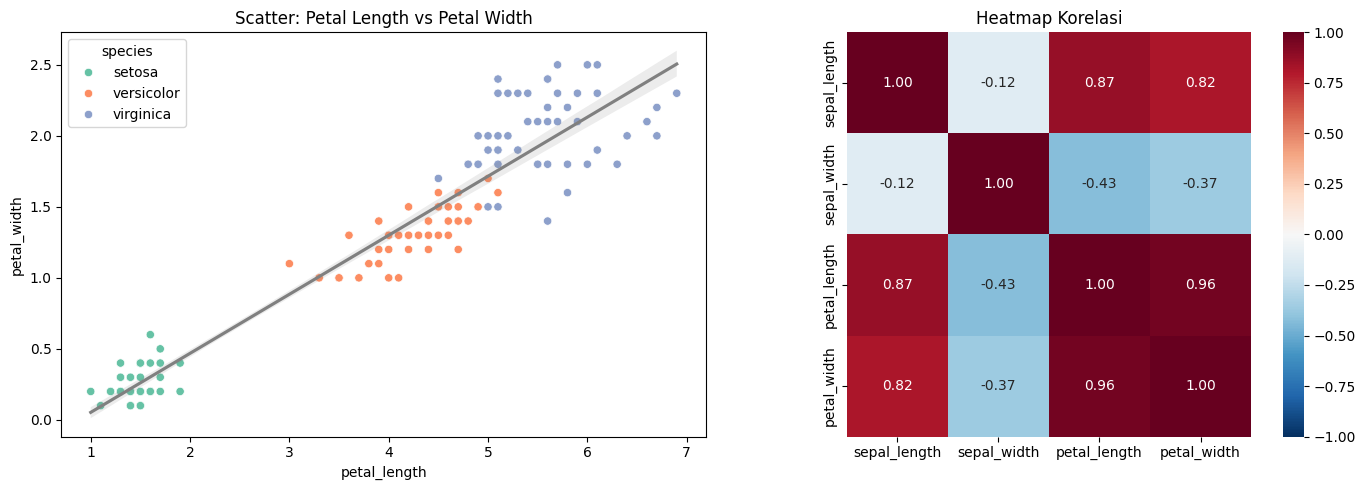

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

Secara keseluruhan, fitur Petal (kelopak) adalah pembeda yang paling efektif untuk mengklasifikasikan spesies bunga Iris karena memiliki korelasi yang sangat konsisten dan pola pemisahan kelompok yang jelas dibandingkan fitur Sepal.



---


#### Kesimpulan

---



<p>Pada pertemuan ini dipelajari dasar-dasar statistika dalam Data Science, meliputi statistika deskriptif (mean, median, modus, varians, standar deviasi, kuartil, dan IQR), distribusi data, analisis univariat menggunakan histogram, boxplot, dan violin plot, serta analisis bivariat menggunakan scatter plot dan korelasi Pearson maupun Spearman. Seluruh konsep diterapkan menggunakan Python dan dataset nyata.</br></br>
<p>Temuan utama dari materi ini adalah bahwa statistika deskriptif membantu memahami karakteristik dasar data, analisis distribusi membantu mengenali pola dan outlier, sedangkan analisis bivariat memungkinkan identifikasi hubungan antarvariabel melalui korelasi dan visualisasi. Selain itu, korelasi dapat menunjukkan kekuatan hubungan antarvariabel, namun tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat.